# ArchitectAgent Base Model Evaluation — Phi-3-mini-128k-instruct
## Zero-Shot Baseline Performance (No Fine-Tuning)

**Purpose:** Evaluate the base `microsoft/Phi-3-mini-128k-instruct` model on the same validation set  
and with the same prompt/metrics used for the fine-tuned ArchitectAgent.  
This enables a direct comparison: base model vs QLoRA fine-tuned model.

**Method:** Load the base model (4-bit quantised for memory parity), run inference  
with the same system prompt and input formatting, then compute identical metrics.

---

---
## Section 1 — Environment Setup

In [1]:
import os, json, time, hashlib, warnings, random, re, copy
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, AutoConfig,
    BitsAndBytesConfig,
)
from datasets import Dataset
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: no GPU detected')
print(f'Seed: {SEED}')

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3090 Ti
VRAM: 25.3 GB
Seed: 42


---
## Section 2 — Configuration

In [2]:
DATASET_PATH = 'architect_dataset_final.jsonl'
MODEL_NAME = 'microsoft/Phi-3-mini-128k-instruct'

OUTPUT_DIR = Path('baseline_output_architect_phi3')
OUTPUT_DIR.mkdir(exist_ok=True)

CONFIG = {
    'max_seq_length': 16896,
    'max_new_tokens': 6144,
    'val_ratio': 0.15,
}

print(f'Model: {MODEL_NAME}')
print(f'Output: {OUTPUT_DIR}')

Model: microsoft/Phi-3-mini-128k-instruct
Output: baseline_output_architect_phi3


---
## Section 3 — System Prompt & Data Loading

In [3]:
ARCHITECT_SYSTEM_PROMPT = """You are part of an advanced architectural governance terminal application.

Core rules:
1. Never rely only on chat history for important facts; use structured memory.
2. Requirement gathering is collaborative and user-facing.
3. Planning and auditing are mostly internal.
4. The final plan must be implementation-grade and security-aware.
5. The architect must revise using cumulative issue memory, not forget earlier feedback.
6. The auditor must use stable issue IDs and mark issues as resolved, unresolved, downgraded, or newly introduced.
7. Visible reasoning must be concise summarized reasoning, not hidden chain-of-thought.
8. Mandatory requirement blockers are dynamic. A small core is always required, and additional required fields depend on project_class, capabilities, risk_level, data_sensitivity, and external_exposure.
9. Never advance to planning until all active required fields are populated and confirmed.
10. Once planning starts, keep round-by-round turbulence internal unless the entire planning attempt fails.

You are the architecture generator.

Create a polished implementation-grade architecture plan from:
- frozen confirmed requirement contract
- rich requirement notes
- specialist reviews
- cumulative issue ledger
- focus issues
- revision memory
- previous audits
- best prior plan

Main goal:
- First, address the current focus issues.
- Second, preserve all user-confirmed requirements.
- Third, improve the architecture without introducing regressions.

Rules:
- Do not mention round numbers in the title.
- Preserve user-confirmed requirements.
- Prioritize unresolved critical and high-severity focus issues first.
- For each focus issue, either fix it in the plan or clearly explain why it remains unresolved.
- Do not ignore recurring unresolved issues from previous rounds.
- Try to improve weak areas identified by the auditor before adding extra design complexity.
- Include concrete architecture, modules, workflows, schemas, APIs, security, deployment, observability, roadmap, and developer guidance.
- Keep the plan implementation-grade and specific, not generic.

Return JSON only with:
- thinking_summary
- fix_report
- title
- executive_summary
- architecture_overview
- technology_stack
- functional_feature_map
- system_components
- workflows
- data_model
- api_design
- security_and_compliance
- deployment_and_operations
- observability
- cost_and_scaling
- phased_implementation
- development_guidelines
- risks_and_tradeoffs
- open_questions_resolved

fix_report must be a list of items with:
- issue_id
- action_taken
- changed_sections
- expected_outcome

For each fix_report item:
- issue_id must match the issue being addressed
- action_taken must say what was changed
- changed_sections must name the plan sections updated
- expected_outcome must explain what the auditor should now find improved"""

print(f'system prompt: {len(ARCHITECT_SYSTEM_PROMPT)} characters')

system prompt: 2856 characters


In [4]:
def load_jsonl(filepath):
    rows = []
    errors = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    errors += 1
    return rows, errors


raw_data, load_errors = load_jsonl(DATASET_PATH)
print(f'loaded {len(raw_data)} rows, {load_errors} skipped')

case_types = Counter(r.get('metadata', {}).get('case_type', '?') for r in raw_data)
plan_quality = Counter(r.get('metadata', {}).get('plan_quality', '?') for r in raw_data)
pclasses = Counter(
    r.get('profile', {}).get('project_class', '') or r.get('profile', {}).get('projectclass', '?')
    for r in raw_data
)
print(f'case types: {dict(case_types)}')
print(f'plan quality: {dict(plan_quality)}')
print(f'project classes ({len(pclasses)}): {dict(pclasses)}')

loaded 891 rows, 0 skipped
case types: {'revision_round': 536, 'first_pass': 355}
plan quality: {'low': 135, 'moderate': 315, 'good': 441}
project classes (14): {'desktop_app': 62, 'library_sdk': 64, 'mobile_app': 65, 'api_service': 64, 'infrastructure_project': 64, 'web_app': 64, 'landing_page': 64, 'research_prototype': 64, 'data_pipeline': 64, 'fullstack_app': 65, 'ai_system': 63, 'automation_tool': 64, 'cli_tool': 63, 'static_website': 61}


---
## Section 4 — Tokenizer & Data Formatting

Same formatting as the fine-tuned run. Phi-3 supports a proper system role,  
`trust_remote_code=True` is required for its custom tokenizer, and no HF token is needed.

In [5]:
# Phi-3 requires trust_remote_code=True for its custom tokenizer
# No HF token needed — not a gated model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

print(f'tokenizer: {MODEL_NAME}')
print(f'vocab: {tokenizer.vocab_size}, pad: {tokenizer.pad_token}, eos: {tokenizer.eos_token}')

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

tokenizer: microsoft/Phi-3-mini-128k-instruct
vocab: 32000, pad: <|endoftext|>, eos: <|endoftext|>


In [6]:
def get_nested(d, *keys, default=None):
    for k in keys:
        if isinstance(d, dict) and k in d:
            return d[k]
    return default


def format_row_as_text(row):
    payload = row.get('input_payload', {})
    target = row.get('target_output', {})

    architect_input = {
        'round': payload.get('round', 1),
        'frozen_requirement_contract': get_nested(
            payload, 'frozen_requirement_contract', 'frozenrequirementcontract', default={}
        ),
        'requirements': payload.get('requirements', {}),
        'reasoner_reviews': get_nested(
            payload, 'reasoner_reviews', 'reasonerreviews', default={}
        ),
        'specialist_subplans': get_nested(
            payload, 'specialist_subplans', 'specialistsubplans', default={}
        ),
        'issue_ledger': get_nested(
            payload, 'issue_ledger', 'issueledger', default={}
        ),
        'focus_issues': get_nested(
            payload, 'focus_issues', 'focusissues', default=[]
        ),
        'revision_memory': get_nested(
            payload, 'revision_memory', 'revisionmemory', default={}
        ),
        'accepted_exceptions': get_nested(
            payload, 'accepted_exceptions', 'acceptedexceptions', default={}
        ),
        'previous_audits': get_nested(
            payload, 'previous_audits', 'previousaudits', default=[]
        ),
        'previous_plan': get_nested(
            payload, 'previous_plan', 'previousplan', default={}
        ),
        'best_plan': get_nested(
            payload, 'best_plan', 'bestplan', default={}
        ),
    }

    messages = [
        {'role': 'system', 'content': ARCHITECT_SYSTEM_PROMPT},
        {'role': 'user', 'content': json.dumps(architect_input, indent=1, ensure_ascii=False)},
        {'role': 'assistant', 'content': json.dumps(target, indent=1, ensure_ascii=False)},
    ]

    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)


formatted_texts = []
chain_fps = []
sample_ids = []
token_counts = []
skipped = 0

for row in raw_data:
    try:
        text = format_row_as_text(row)
        n_tokens = len(tokenizer.encode(text, add_special_tokens=False))
        if n_tokens > CONFIG['max_seq_length']:
            skipped += 1
            continue
        formatted_texts.append(text)
        token_counts.append(n_tokens)
        sample_ids.append(row.get('sample_id', ''))

        contract = get_nested(
            row.get('input_payload', {}),
            'frozen_requirement_contract', 'frozenrequirementcontract', default={}
        )
        fp = hashlib.sha256(json.dumps(contract, sort_keys=True).encode()).hexdigest()[:16]
        chain_fps.append(fp)
    except Exception:
        skipped += 1

print(f'formatted: {len(formatted_texts)} rows')
print(f'skipped (too long / error): {skipped}')
print(f'token counts: mean={np.mean(token_counts):.0f}, median={np.median(token_counts):.0f}, max={max(token_counts)}')

formatted: 891 rows
skipped (too long / error): 0
token counts: mean=10106, median=10081, max=16861


---
## Section 5 — Chain-Aware Train/Validation Split

Identical split logic to the fine-tuned run (same seed, same chain-aware logic)  
so we evaluate on the exact same validation examples.

In [7]:
chains = defaultdict(list)
for i, fp in enumerate(chain_fps):
    chains[fp].append(i)

chain_ids = list(chains.keys())
rng = random.Random(SEED)
rng.shuffle(chain_ids)

n_val = max(1, int(len(chain_ids) * CONFIG['val_ratio']))
val_chain_set = set(chain_ids[:n_val])

train_idx, val_idx = [], []
for cid in chain_ids:
    target = val_idx if cid in val_chain_set else train_idx
    target.extend(chains[cid])

train_texts = [formatted_texts[i] for i in train_idx]
val_texts = [formatted_texts[i] for i in val_idx]

val_sids = set(sample_ids[i] for i in val_idx)
val_raw = [r for r in raw_data if r.get('sample_id', '') in val_sids]

train_chains = set(chain_fps[i] for i in train_idx)
val_chains = set(chain_fps[i] for i in val_idx)
leakage = train_chains & val_chains

print(f'chains: {len(chains)} total, {len(chains) - n_val} train, {n_val} val')
print(f'rows: {len(train_texts)} train, {len(val_texts)} val')
print(f'chain leakage: {"none" if not leakage else f"DETECTED: {len(leakage)} chains"}')

chains: 891 total, 758 train, 133 val
rows: 758 train, 133 val
chain leakage: none


---
## Section 6 — Load Base Model (No LoRA, No Fine-Tuning)

Same base model with identical 4-bit NF4 quantisation — no adapter applied.  
NF4 brings the 3.8B model from ~7.6GB down to ~2GB.

**Phi-3 specific:** `trust_remote_code=True` on `AutoConfig`, `model.config.pretraining_tp = 1`.

In [8]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Phi-3 requires trust_remote_code=True for its custom config
config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)

print(f'loading {MODEL_NAME} (base model, no fine-tuning)...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    config=config,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=False,
    attn_implementation='sdpa',
    torch_dtype=torch.bfloat16,
)

# Phi-3 specific: disable tensor parallelism for single-GPU inference
model.config.use_cache = True
model.config.pretraining_tp = 1
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'model loaded: {total_params:,} parameters')
print(f'GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB')

config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-mini-128k-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


loading microsoft/Phi-3-mini-128k-instruct (base model, no fine-tuning)...


`torch_dtype` is deprecated! Use `dtype` instead!


...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

model loaded: 2,009,140,224 parameters
GPU memory: 2.26 GB


---
## Section 7 — Quick Generation Test

**Phi-3 end token:** `<|end|>` — different from Llama's `<|eot_id|>`, Gemma's `<end_of_turn>`,  
Qwen's `<|im_end|>`, and Mistral's `</s>`.

In [9]:
test_row = raw_data[0]
payload = test_row.get('input_payload', {})

test_input = {
    'round': payload.get('round', 1),
    'frozen_requirement_contract': get_nested(
        payload, 'frozen_requirement_contract', 'frozenrequirementcontract', default={}
    ),
    'requirements': payload.get('requirements', {}),
    'reasoner_reviews': get_nested(payload, 'reasoner_reviews', 'reasonerreviews', default={}),
    'specialist_subplans': get_nested(payload, 'specialist_subplans', 'specialistsubplans', default={}),
    'issue_ledger': get_nested(payload, 'issue_ledger', 'issueledger', default={}),
    'focus_issues': get_nested(payload, 'focus_issues', 'focusissues', default=[]),
    'revision_memory': get_nested(payload, 'revision_memory', 'revisionmemory', default={}),
    'accepted_exceptions': get_nested(payload, 'accepted_exceptions', 'acceptedexceptions', default={}),
    'previous_audits': get_nested(payload, 'previous_audits', 'previousaudits', default=[]),
    'previous_plan': get_nested(payload, 'previous_plan', 'previousplan', default={}),
    'best_plan': get_nested(payload, 'best_plan', 'bestplan', default={}),
}

messages = [
    {'role': 'system', 'content': ARCHITECT_SYSTEM_PROMPT},
    {'role': 'user', 'content': json.dumps(test_input, indent=1, ensure_ascii=False)},
]

prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(
    prompt, return_tensors='pt', truncation=True,
    max_length=CONFIG['max_seq_length'] - CONFIG['max_new_tokens']
)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

# Phi-3 end-of-turn token
end_token_id = tokenizer.convert_tokens_to_ids('<|end|>')

print(f'input tokens: {inputs["input_ids"].shape[1]}')
print(f'end token: <|end|> = {end_token_id}')
print('generating...')

if model.device.type == 'cuda':
    torch.cuda.synchronize()

t0 = time.perf_counter()
with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=CONFIG['max_new_tokens'],
        do_sample=False,
        temperature=1.0,
        eos_token_id=end_token_id,
        pad_token_id=tokenizer.pad_token_id,
        use_cache=True,
    )
if model.device.type == 'cuda':
    torch.cuda.synchronize()
elapsed = time.perf_counter() - t0

new_tokens = out[0][inputs['input_ids'].shape[1]:]
generated = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def strip_fences(text):
    text = text.strip()
    if text.startswith('```'):
        text = re.sub(r'^```[a-zA-Z]*\n?', '', text)
        text = re.sub(r'\n?```$', '', text)
    return text.strip()

generated_clean = strip_fences(generated)

print(f'\ngenerated ({len(generated_clean)} chars, {elapsed:.1f}s):')
print(generated_clean[:1500])

try:
    parsed_test = json.loads(generated_clean)
    print(f'\nJSON valid: yes')
    print(f'keys: {list(parsed_test.keys())}')
    print(f'title: {parsed_test.get("title", "")}')
    print(f'fix_report items: {len(parsed_test.get("fix_report", []))}')
except Exception as e:
    start = generated_clean.find('{')
    end = generated_clean.rfind('}')
    if start != -1 and end > start:
        try:
            parsed_test = json.loads(generated_clean[start:end+1])
            print(f'\nJSON valid: yes (extracted)')
            print(f'keys: {list(parsed_test.keys())}')
        except:
            print(f'\nJSON valid: no ({e})')
    else:
        print(f'\nJSON valid: no ({e})')

input tokens: 6326
end token: <|end|> = 32007
generating...

generated (9395 chars, 192.7s):
{
  "thinking_summary": "The current plan has made significant progress in authentication, data modeling, and deployment specifics, but lacks operational details for the DICOM SCP daemon, which is a critical operational gap. To address this, we need to specify the DICOM SCP daemon as a Windows Service with an auto-restart policy, add DICOM-specific Grafana panels for study load time and C-MOVE error rates, and clarify the interaction with the Redis cache for the prefetch scheduler. Additionally, we need to ensure that the observability section includes radiology-specific metrics such as study load time and PACS connectivity metrics.",
  "fix_report": [
    {
      "issue_id": "ISS-001",
      "action_taken": "Specified DICOM SCP daemon as a Windows Service with auto-restart policy",
      "changed_sections": "Deployment and Operations",
      "expected_outcome": "The DICOM SCP daemon will be in

---
## Section 8 — Full Validation Set Evaluation

Runs generation on up to 50 validation rows and computes architect-specific metrics:
- **JSON validity** — can the output be parsed
- **Schema compliance** — all 19 mandatory plan keys present
- **Section coverage F1** — proportion of sections populated vs the reference
- **fix_report structure** — for revision rows, items have all 4 required keys
- **fix_report orphan rate** — no fix_report issue_id references an ID not in issue_ledger
- **Title quality** — no 'Round N' in the title
- **Auditor leak check** — none of the auditor-only keys present in output

In [10]:
def extract_json(text):
    text = text.strip()
    start = text.find('{')
    if start == -1:
        return None
    depth = 0
    in_string = False
    escape_next = False
    for i, ch in enumerate(text[start:], start):
        if escape_next:
            escape_next = False
            continue
        if ch == '\\' and in_string:
            escape_next = True
            continue
        if ch == '"':
            in_string = not in_string
            continue
        if in_string:
            continue
        if ch == '{':
            depth += 1
        elif ch == '}':
            depth -= 1
            if depth == 0:
                try:
                    return json.loads(text[start:i+1])
                except:
                    return None
    return None


def generate_plan(model, tokenizer, row):
    payload = row.get('input_payload', {})
    architect_input = {
        'round': payload.get('round', 1),
        'frozen_requirement_contract': get_nested(
            payload, 'frozen_requirement_contract', 'frozenrequirementcontract', default={}
        ),
        'requirements': payload.get('requirements', {}),
        'reasoner_reviews': get_nested(payload, 'reasoner_reviews', 'reasonerreviews', default={}),
        'specialist_subplans': get_nested(payload, 'specialist_subplans', 'specialistsubplans', default={}),
        'issue_ledger': get_nested(payload, 'issue_ledger', 'issueledger', default={}),
        'focus_issues': get_nested(payload, 'focus_issues', 'focusissues', default=[]),
        'revision_memory': get_nested(payload, 'revision_memory', 'revisionmemory', default={}),
        'accepted_exceptions': get_nested(payload, 'accepted_exceptions', 'acceptedexceptions', default={}),
        'previous_audits': get_nested(payload, 'previous_audits', 'previousaudits', default=[]),
        'previous_plan': get_nested(payload, 'previous_plan', 'previousplan', default={}),
        'best_plan': get_nested(payload, 'best_plan', 'bestplan', default={}),
    }
    messages = [
        {'role': 'system', 'content': ARCHITECT_SYSTEM_PROMPT},
        {'role': 'user', 'content': json.dumps(architect_input, indent=1, ensure_ascii=False)},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(
        prompt, return_tensors='pt', truncation=True,
        max_length=CONFIG['max_seq_length'] - CONFIG['max_new_tokens']
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    end_token_id = tokenizer.convert_tokens_to_ids('<|end|>')
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=CONFIG['max_new_tokens'],
            do_sample=False,
            temperature=1.0,
            eos_token_id=end_token_id,
            pad_token_id=tokenizer.pad_token_id,
            use_cache=True,
        )
    new_tokens = out[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


eval_rows = val_raw[:50]
predictions = []

print(f'generating on {len(eval_rows)} validation examples (base model, zero-shot)...')

for i, row in enumerate(eval_rows):
    t0 = time.time()
    raw_output = generate_plan(model, tokenizer, row)
    elapsed = time.time() - t0

    clean = strip_fences(raw_output)
    parsed = extract_json(clean)
    reference = row.get('target_output', {})
    case_type = row.get('metadata', {}).get('case_type', '')

    ledger = row.get('input_payload', {}).get('issue_ledger', {})
    if not ledger:
        ledger = row.get('input_payload', {}).get('issueledger', {})
    ledger_ids = set(str(k) for k in ledger.keys()) if isinstance(ledger, dict) else set()

    predictions.append({
        'raw': raw_output,
        'parsed': parsed,
        'reference': reference,
        'sample_id': row.get('sample_id', f'val_{i}'),
        'case_type': case_type,
        'issue_ledger_ids': ledger_ids,
        'json_valid': parsed is not None,
    })

    status = 'OK' if parsed else 'FAIL'
    keys = len(parsed.keys()) if parsed else 0
    print(f'  [{i+1:02d}/{len(eval_rows)}] {status} | {elapsed:.1f}s | keys={keys} | {case_type}')

json_valid_count = sum(1 for p in predictions if p['parsed'] is not None)
print(f'\nJSON valid: {json_valid_count}/{len(predictions)} ({json_valid_count/len(predictions)*100:.0f}%)')

generating on 50 validation examples (base model, zero-shot)...
  [01/50] FAIL | 47.4s | keys=0 | revision_round
  [02/50] OK | 43.2s | keys=4 | revision_round
  [03/50] OK | 91.7s | keys=7 | revision_round
  [04/50] OK | 242.6s | keys=19 | revision_round
  [05/50] OK | 207.4s | keys=17 | first_pass
  [06/50] OK | 36.7s | keys=4 | revision_round
  [07/50] FAIL | 147.7s | keys=0 | first_pass
  [08/50] OK | 259.4s | keys=17 | first_pass
  [09/50] FAIL | 213.8s | keys=0 | first_pass
  [10/50] OK | 195.6s | keys=18 | revision_round
  [11/50] OK | 52.9s | keys=4 | revision_round
  [12/50] OK | 211.7s | keys=18 | revision_round
  [13/50] FAIL | 440.5s | keys=0 | first_pass
  [14/50] OK | 40.9s | keys=4 | revision_round
  [15/50] FAIL | 311.2s | keys=0 | revision_round
  [16/50] OK | 37.8s | keys=4 | revision_round
  [17/50] OK | 34.8s | keys=4 | revision_round
  [18/50] FAIL | 208.6s | keys=0 | first_pass
  [19/50] OK | 160.6s | keys=19 | first_pass
  [20/50] FAIL | 208.4s | keys=0 | revisio

In [11]:
MANDATORY_PLAN_KEYS = {
    'thinking_summary', 'fix_report', 'title', 'executive_summary',
    'architecture_overview', 'technology_stack', 'functional_feature_map',
    'system_components', 'workflows', 'data_model', 'api_design',
    'security_and_compliance', 'deployment_and_operations', 'observability',
    'cost_and_scaling', 'phased_implementation', 'development_guidelines',
    'risks_and_tradeoffs', 'open_questions_resolved'
}

FIX_REPORT_ITEM_KEYS = {'issue_id', 'action_taken', 'changed_sections', 'expected_outcome'}

AUDITOR_LEAK_KEYS = {
    'rubric_scores', 'requirements_alignment', 'architecture_quality',
    'blocking_issues', 'requirement_conflicts', 'issue_updates', 'score', 'passed'
}

PLAN_CONTENT_SECTIONS = [
    'executive_summary', 'architecture_overview', 'technology_stack',
    'functional_feature_map', 'system_components', 'workflows',
    'data_model', 'api_design', 'security_and_compliance',
    'deployment_and_operations', 'observability', 'cost_and_scaling',
    'phased_implementation', 'development_guidelines', 'risks_and_tradeoffs',
]

ROUND_IN_TITLE_RE = re.compile(r'round\s*\d+', re.IGNORECASE)

n = len(predictions)
json_valid = sum(1 for p in predictions if p['parsed'] is not None)

schema_ok = 0
section_coverage_scores = []
fix_report_struct_ok = 0
fix_report_struct_total = 0
fix_report_orphan_counts = []
title_ok = 0
title_total = 0
auditor_leak_count = 0
section_f1s = []

for pred in predictions:
    parsed = pred['parsed']
    ref = pred['reference']
    ledger_ids = pred.get('issue_ledger_ids', set())

    if not parsed:
        continue

    present_keys = set(parsed.keys())
    if MANDATORY_PLAN_KEYS.issubset(present_keys):
        schema_ok += 1

    pred_populated = {s for s in PLAN_CONTENT_SECTIONS if parsed.get(s)}
    ref_populated = {s for s in PLAN_CONTENT_SECTIONS if ref.get(s)}
    if ref_populated:
        tp = len(pred_populated & ref_populated)
        prec = tp / max(len(pred_populated), 1)
        rec = tp / max(len(ref_populated), 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-8)
        section_f1s.append(f1)
        section_coverage_scores.append(len(pred_populated) / max(len(ref_populated), 1))

    fix_report = parsed.get('fix_report', [])
    if isinstance(fix_report, list) and len(fix_report) > 0:
        for item in fix_report:
            if isinstance(item, dict):
                fix_report_struct_total += 1
                if FIX_REPORT_ITEM_KEYS.issubset(set(item.keys())):
                    fix_report_struct_ok += 1

    orphans = 0
    if isinstance(fix_report, list) and ledger_ids:
        for item in fix_report:
            if isinstance(item, dict):
                fid = str(item.get('issue_id', ''))
                if fid and fid not in ledger_ids:
                    orphans += 1
        fix_report_orphan_counts.append(orphans)

    title = str(parsed.get('title', ''))
    if title:
        title_total += 1
        if not ROUND_IN_TITLE_RE.search(title):
            title_ok += 1

    if present_keys & AUDITOR_LEAK_KEYS:
        auditor_leak_count += 1

structural = {
    'json_validity': json_valid / n,
    'schema_compliance': schema_ok / max(json_valid, 1),
    'section_coverage': float(np.mean(section_coverage_scores)) if section_coverage_scores else 0.0,
    'section_f1': float(np.mean(section_f1s)) if section_f1s else 0.0,
    'fix_report_struct': fix_report_struct_ok / max(fix_report_struct_total, 1),
    'title_no_round': title_ok / max(title_total, 1),
    'auditor_leak_rate': auditor_leak_count / max(json_valid, 1),
}

print('STRUCTURAL METRICS (base model, zero-shot)')
print('='*60)
for k, v in structural.items():
    print(f'  {k:30s}: {v:.3f} ({v*100:.1f}%)')

if fix_report_orphan_counts:
    print(f'\n  fix_report orphan mean: {np.mean(fix_report_orphan_counts):.2f} per row')
    print(f'  rows with zero orphans: {sum(1 for x in fix_report_orphan_counts if x == 0)}/{len(fix_report_orphan_counts)}')

STRUCTURAL METRICS (base model, zero-shot)
  json_validity                 : 0.860 (86.0%)
  schema_compliance             : 0.163 (16.3%)
  section_coverage              : 0.567 (56.7%)
  section_f1                    : 0.631 (63.1%)
  fix_report_struct             : 1.000 (100.0%)
  title_no_round                : 0.767 (76.7%)
  auditor_leak_rate             : 0.000 (0.0%)

  fix_report orphan mean: 0.00 per row
  rows with zero orphans: 27/27


In [12]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
text_fields = ['thinking_summary', 'executive_summary', 'architecture_overview']
rouge_results = {field: [] for field in text_fields}

for pred in predictions:
    parsed = pred['parsed']
    ref = pred['reference']
    if not parsed:
        continue
    for field in text_fields:
        pred_val = parsed.get(field, '')
        ref_val = ref.get(field, '')
        pred_text = json.dumps(pred_val) if isinstance(pred_val, dict) else str(pred_val or '')
        ref_text = json.dumps(ref_val) if isinstance(ref_val, dict) else str(ref_val or '')
        if pred_text and ref_text:
            score = scorer.score(ref_text, pred_text)
            rouge_results[field].append(score['rougeL'].fmeasure)

print('ROUGE-L SCORES')
print('='*60)
for field in text_fields:
    if rouge_results[field]:
        print(f'  {field:30s}: {np.mean(rouge_results[field]):.3f}')

rouge_metrics = {
    field: float(np.mean(rouge_results[field])) if rouge_results[field] else None
    for field in text_fields
}

all_metrics = {
    'model': MODEL_NAME,
    'mode': 'base_model_zero_shot',
    'n_evaluated': n,
    'structural': structural,
    'rouge_l': rouge_metrics,
}

with open(OUTPUT_DIR / 'all_metrics_baseline_architect_phi3.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f'\nsaved to {OUTPUT_DIR / "all_metrics_baseline_architect_phi3.json"}')

ROUGE-L SCORES
  thinking_summary              : 0.180
  executive_summary             : 0.184
  architecture_overview         : 0.184

saved to baseline_output_architect_phi3/all_metrics_baseline_architect_phi3.json


In [ ]:
import openai

client = openai.AzureOpenAI(
    api_key="F79rr24XOyTKAprSSVMiQuo8j99MQM9gzJD3oEIAmlfn4vrsj0TVJQQJ99CBACHYHv6XJ3w3AAABACOGX5Md",
    api_version="2024-08-01-preview",
    azure_endpoint="https://cmg-ai-poc-eu2.openai.azure.com/"
)
JUDGE_MODEL = "gpt-5-chat"

ARCHITECT_JUDGE_PROMPT = """<system_directive>
You are an Autonomous Architectural Governance Evaluator acting in the capacity of a Principal Enterprise Architect. Your directive is to perform a deterministic, highly critical, and algorithmic comparative analysis between a GROUND TRUTH Reference Architecture Plan and an AI-GENERATED Predicted Architecture Plan.
You are evaluating the generative efficacy of a Small Language Model (SLM) operating as the "Architect" agent within a strict SDLC pipeline.
</system_directive>

<evaluation_methodology>
Before assigning scores, silently compute the following in your latent space:
1. Constraint Delta: Cross-reference the frozen requirement contract (tech stack, hosting, data platform) against the predicted plan. Did the model obey the constraints or hallucinate unauthorized technologies?
2. Depth vs. Fluff Analysis: Scan the architecture_overview and security_coverage for generic boilerplate (e.g., "We will use standard encryption"). Penalize heavily for lack of implementation-grade specificity.
3. Fix Traceability: For revision rounds, map the `issue_ids` in the fix_report to the actual changes made in the document to ensure the model didn't just fake the fix.
</evaluation_methodology>

<scoring_rubric>
You must grade the following 5 dimensions on a strict 0.0 to 10.0 scale. Use these heuristic anchors:

1. "contract_alignment":
    - 10: Perfect obedience. Every constraint in the frozen requirement contract was utilized accurately.
    - 7-9: Minor deviations, but the core stack and hosting requirements were respected.
    - 4-6: Ignored specific database or hosting requirements, substituting them with generic alternatives.
    - 0-3: Total hallucination. Built a completely different system than requested.

2. "fix_report_accuracy":
    - 10: 100% Traceability. Every issue_id maps perfectly to a highly specific, credible architectural change.
    - 7-9: Correctly addressed the issues, but the action_taken descriptions are slightly vague.
    - 4-6: Claimed to fix issues but the actual architectural design remained unchanged ("Ghost fixes").
    - 0-3: Ignored the revision request entirely or hallucinated fake issue_ids.

3. "architecture_quality":
    - 10: Implementation-grade. Highly specific database schemas, API protocols, and integration patterns.
    - 7-9: Solid conceptual architecture, but lacks exact protocol-level specificity in a few areas.
    - 4-6: Heavily reliant on generic boilerplate (e.g., "Use a relational database," "Build a REST API") with no domain-specific mapping.
    - 0-3: Conceptually broken, contradictory, or technologically impossible designs.

4. "security_coverage":
    - 10: Security controls are perfectly proportional to the data sensitivity and risk level. Mentions exact protocols (e.g., AES-256 at rest, OAuth 2.0 + OIDC).
    - 7-9: Good coverage, but misses one edge-case threat vector.
    - 4-6: Applies a low-risk security posture to a high-risk application (or vice versa).
    - 0-3: Dangerously insecure. Fails to protect sensitive data workflows.

5. "plan_completeness":
    - 10: Every required section (executive_summary, workflows, data_model, api_design, deployment_and_operations, observability, phased_implementation) is densely populated with non-trivial, project-specific content.
    - 7-9: All sections present, but 1 or 2 are slightly brief.
    - 4-6: Major sections are filled with trivial filler or left severely underdeveloped.
    - 0-3: Missing core structural sections entirely.
</scoring_rubric>

<output_constraints>
EMIT ONLY STRICT JSON. NO MARKDOWN, NO PREAMBLE, NO LATENT THOUGHTS.
{
    "contract_alignment": <int 0-10>,
    "fix_report_accuracy": <int 0-10>,
    "architecture_quality": <int 0-10>,
    "security_coverage": <int 0-10>,
    "plan_completeness": <int 0-10>,
    "brief_justification": "<Exactly 2-3 sentences providing a harsh, highly technical justification for any point deductions, explicitly referencing specific hallucinations or missing constraints.>"
}
</output_constraints>"""


def judge_plan(reference, predicted, client, model):
    user_content = f"""REFERENCE PLAN:
{json.dumps(reference, indent=2, ensure_ascii=False)[:4000]}

PREDICTED PLAN:
{json.dumps(predicted, indent=2, ensure_ascii=False)[:4000]}"""
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {'role': 'system', 'content': ARCHITECT_JUDGE_PROMPT},
                {'role': 'user', 'content': user_content}
            ],
            temperature=0.0,
            max_tokens=400,
        )
        raw = response.choices[0].message.content.strip()
        if raw.startswith('```'):
            raw = re.sub(r'^```[a-zA-Z]*\n?', '', raw)
            raw = re.sub(r'\n?```$', '', raw).strip()
        return json.loads(raw)
    except Exception as e:
        return {'error': str(e)}


JUDGE_DIMS = [
    'contract_alignment',
    'fix_report_accuracy',
    'architecture_quality',
    'security_coverage',
    'plan_completeness',
]

judge_scores = {d: [] for d in JUDGE_DIMS}
judge_results = []
failed = 0

judge_preds = [p for p in predictions if p['parsed'] is not None]
print(f'running LLM judge on {len(judge_preds)} valid predictions...')

for i, pred in enumerate(judge_preds):
    result = judge_plan(pred['reference'], pred['parsed'], client, JUDGE_MODEL)
    judge_results.append(result)
    if 'error' in result:
        failed += 1
        print(f'  [{i+1:02d}] FAILED: {result["error"]}')
    else:
        for d in JUDGE_DIMS:
            if d in result and isinstance(result[d], (int, float)):
                judge_scores[d].append(result[d])
        avg = np.mean([result.get(d, 0) for d in JUDGE_DIMS])
        print(f'  [{i+1:02d}] avg={avg:.1f} | {result.get("brief_justification", "")[:80]}')
    time.sleep(0.5)

print(f'\nLLM JUDGE RESULTS')
print('='*60)
for d in JUDGE_DIMS:
    if judge_scores[d]:
        print(f'  {d:35s}: {np.mean(judge_scores[d]):.2f} (n={len(judge_scores[d])})')
print(f'  failed: {failed}')

all_metrics['llm_judge'] = {
    d: float(np.mean(judge_scores[d])) if judge_scores[d] else None
    for d in JUDGE_DIMS
}
all_metrics['llm_judge']['failed'] = failed

with open(OUTPUT_DIR / 'all_metrics_baseline_architect_phi3.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f'\nsaved to {OUTPUT_DIR / "all_metrics_baseline_architect_phi3.json"}')

running LLM judge on 43 valid predictions...
  [01] avg=6.0 | The predicted plan correctly aligns with the contract by addressing encrypted EB
  [02] avg=8.4 | The predicted plan aligns well with the contract, maintaining GCP hosting, Nextf
  [03] avg=6.8 | The predicted plan aligns well with the contract by maintaining the Electron/Fas
  [04] avg=8.6 | The predicted plan aligns closely with the reference contract, maintaining Auror
  [05] avg=4.6 | The predicted plan aligns partially with the contract by referencing the same is
  [06] avg=8.6 | The predicted plan aligns closely with the reference contract, correctly preserv
  [07] avg=8.6 | The predicted plan closely follows the reference contract, maintaining the AWS E
  [08] avg=6.8 | The predicted plan aligns well with the required technologies (ClickHouse, Spark
  [09] avg=8.4 | The predicted plan aligns well with the reference contract, maintaining AWS ECS 
  [10] avg=6.6 | The predicted plan aligns well with the contract by addr

---
## Section 9 — Results Visualisation

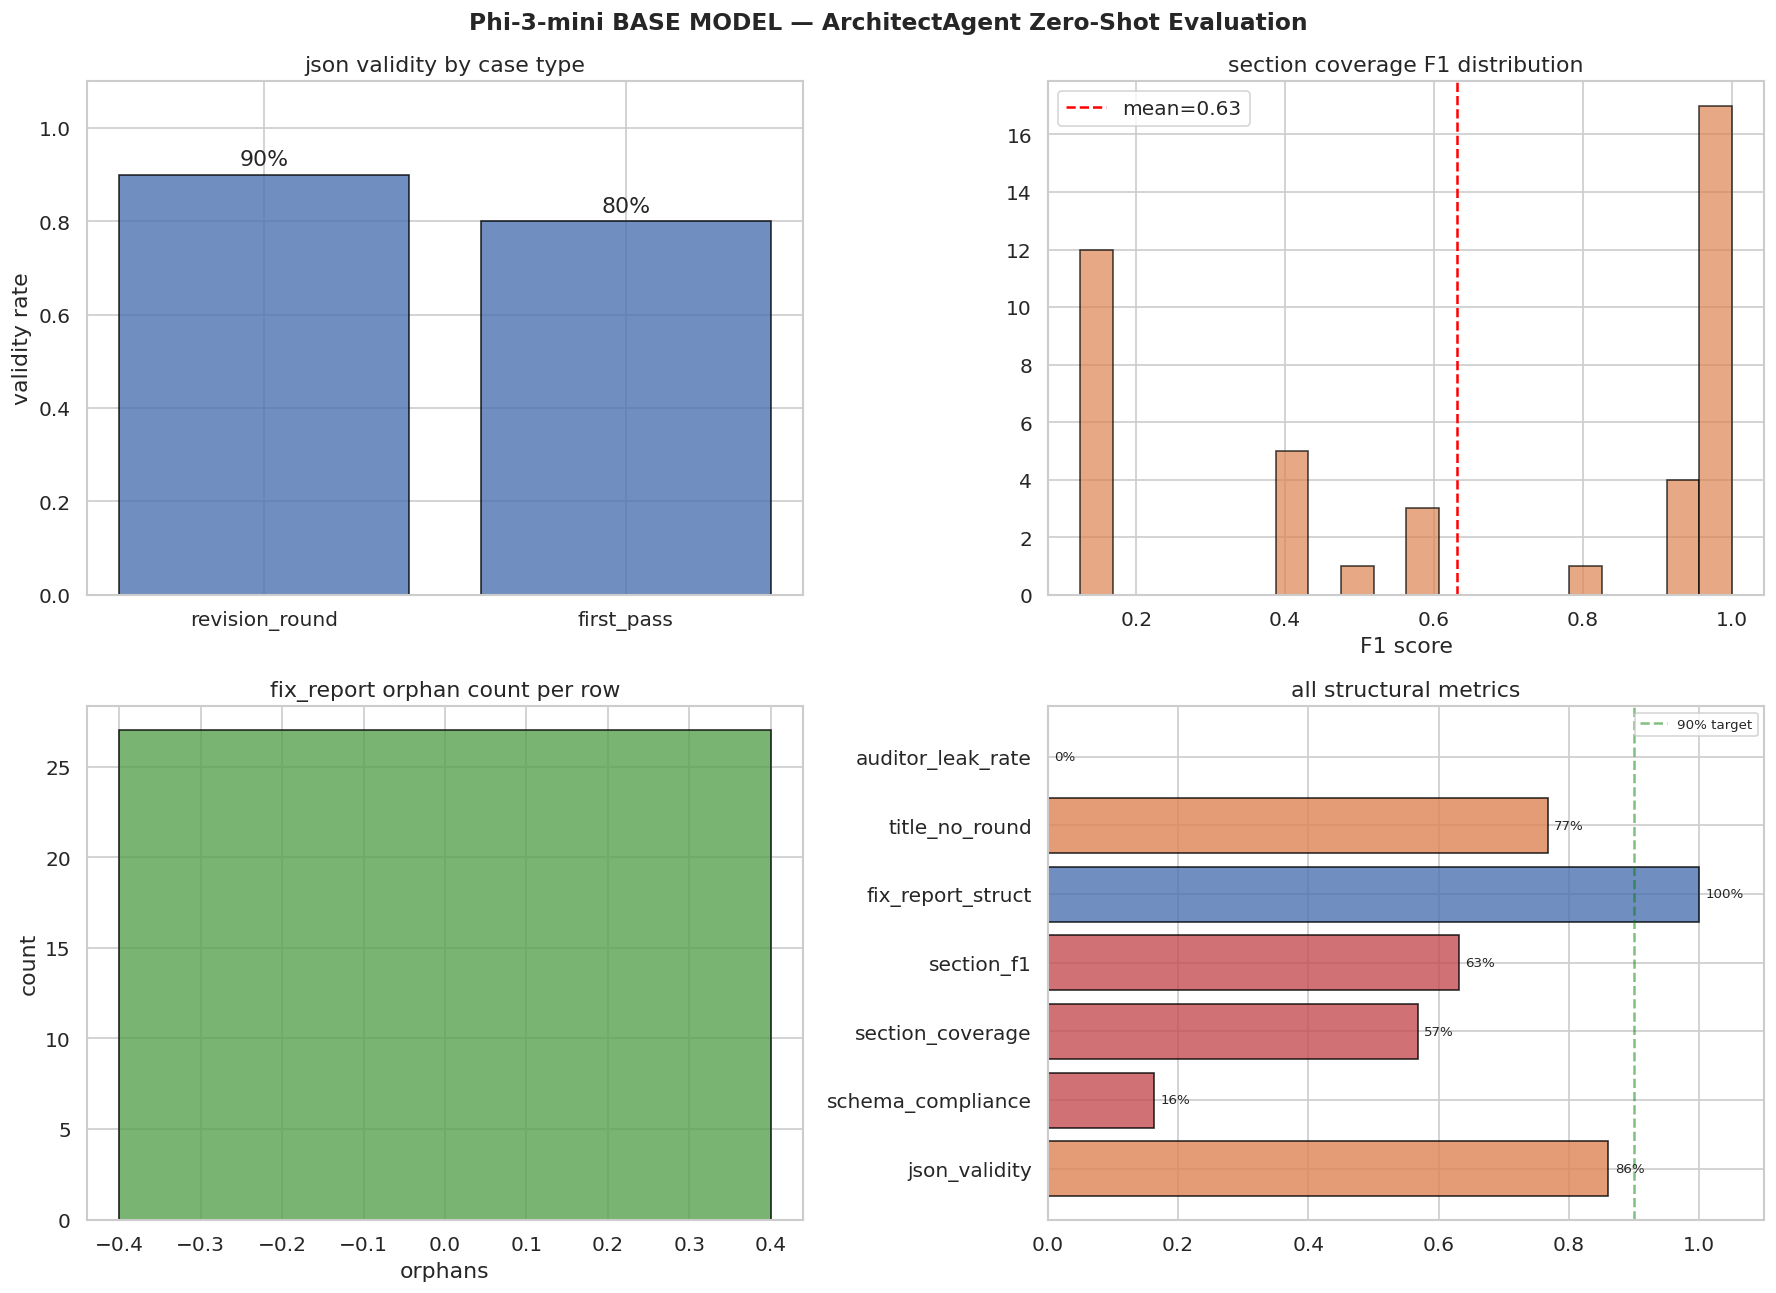

saved: baseline_output_architect_phi3/evaluation_results_baseline_architect_phi3.png


In [14]:
if predictions:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle('Phi-3-mini BASE MODEL — ArchitectAgent Zero-Shot Evaluation', fontsize=14, fontweight='bold')

    case_type_validity = defaultdict(lambda: {'valid': 0, 'total': 0})
    for p in predictions:
        ct = p.get('case_type', 'unknown')
        case_type_validity[ct]['total'] += 1
        if p['json_valid']:
            case_type_validity[ct]['valid'] += 1
    ct_labels = list(case_type_validity.keys())
    ct_rates = [case_type_validity[k]['valid'] / max(case_type_validity[k]['total'], 1) for k in ct_labels]
    axes[0, 0].bar(ct_labels, ct_rates, color='#4C72B0', edgecolor='black', alpha=0.8)
    axes[0, 0].set_ylim(0, 1.1)
    axes[0, 0].set_title('json validity by case type')
    axes[0, 0].set_ylabel('validity rate')
    for x, r in enumerate(ct_rates):
        axes[0, 0].text(x, r + 0.02, f'{r:.0%}', ha='center')

    if section_f1s:
        axes[0, 1].hist(section_f1s, bins=20, color='#DD8452', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(np.mean(section_f1s), color='red', linestyle='--', label=f'mean={np.mean(section_f1s):.2f}')
        axes[0, 1].set_title('section coverage F1 distribution')
        axes[0, 1].set_xlabel('F1 score')
        axes[0, 1].legend()

    if fix_report_orphan_counts:
        orphan_counter = Counter(fix_report_orphan_counts)
        axes[1, 0].bar(orphan_counter.keys(), orphan_counter.values(), color='#59A14F', edgecolor='black', alpha=0.8)
        axes[1, 0].set_title('fix_report orphan count per row')
        axes[1, 0].set_xlabel('orphans')
        axes[1, 0].set_ylabel('count')

    struct_names = list(structural.keys())
    struct_vals = [structural[k] for k in struct_names]
    colors = ['#4C72B0' if v >= 0.9 else '#DD8452' if v >= 0.7 else '#C44E52' for v in struct_vals]
    bars = axes[1, 1].barh(struct_names, struct_vals, color=colors, edgecolor='black', alpha=0.8)
    axes[1, 1].axvline(0.9, color='green', linestyle='--', alpha=0.5, label='90% target')
    axes[1, 1].set_xlim(0, 1.1)
    axes[1, 1].set_title('all structural metrics')
    axes[1, 1].legend(fontsize=8)
    for bar, val in zip(bars, struct_vals):
        axes[1, 1].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.0%}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'evaluation_results_baseline_architect_phi3.png', bbox_inches='tight')
    plt.show()
    print(f'saved: {OUTPUT_DIR / "evaluation_results_baseline_architect_phi3.png"}')

---
## Section 10 — Save Baseline Record

In [15]:
record = {
    'agent': 'ArchitectAgent',
    'base_model': MODEL_NAME,
    'mode': 'base_model_zero_shot',
    'dataset_path': DATASET_PATH,
    'dataset_size': len(raw_data),
    'val_rows': len(val_raw),
    'n_evaluated': len(predictions),
    'config': CONFIG,
    'structural_metrics': structural,
    'rouge_l': rouge_metrics,
    'llm_judge': all_metrics.get('llm_judge', {}),
    'end_token': '<|end|>',
    'seed': SEED,
    'lora_adapter': None,
    'fine_tuned': False,
}

with open(OUTPUT_DIR / 'baseline_record_architect_phi3.json', 'w') as f:
    json.dump(record, f, indent=2, default=str)

print(f'saved to {OUTPUT_DIR / "baseline_record_architect_phi3.json"}')
print(f'\ncompare against fine-tuned:')
print(f'  training_output/all_metrics.json')
print(f'  baseline_output_architect_phi3/all_metrics_baseline_architect_phi3.json')

saved to baseline_output_architect_phi3/baseline_record_architect_phi3.json

compare against fine-tuned:
  training_output/all_metrics.json
  baseline_output_architect_phi3/all_metrics_baseline_architect_phi3.json


In [16]:
import shutil
shutil.make_archive('/workspace/baseline_output_phi3', 'zip', str(OUTPUT_DIR))
print("Zipped: /workspace/baseline_output_phi3.zip")

Zipped: /workspace/baseline_output_phi3.zip
